In [1]:
from modules import *
import numpy as np


In [2]:
files = [
    "Data/Export Industry 10-19.xlsx",
    "Data/Export Industry 20-27.xlsx",
    "Data/Export Industry 28-33.xlsx"
]

# Usage
df = pd.DataFrame()
for file in files:
    dffile = read_orbis_excel(
        file,
        sheet_name="Ergebnisse"
    )
    df = pd.concat([df, dffile])


#replace n.v. with na
df = df.replace('n.v.', np.nan)

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
DESC_COLS = ['Unternehmensname Latin alphabet',
       'NACE Rev. 2 Core Code (4 Ziffern)']

#take num cols and drop 2014 and betriebsertrag
NUM_COLS = [col for col in df.columns if (col not in DESC_COLS) and ('2014' not in col) and ('Betriebsertrag' not in col)]


#drop all who have missing financial information
df = df.dropna(subset=NUM_COLS, how='any')[DESC_COLS + NUM_COLS]
df.describe()

,NACE Rev. 2 Core Code (4 Ziffern),Unnamed: 0,Anlagevermögen tsd EUR 2024,Anlagevermögen tsd EUR 2023,Anlagevermögen tsd EUR 2022,Anlagevermögen tsd EUR 2021,Anlagevermögen tsd EUR 2020,Anlagevermögen tsd EUR 2019,Anlagevermögen tsd EUR 2018,Anlagevermögen tsd EUR 2017,...,Anzahl der Mitarbeiter 2024,Anzahl der Mitarbeiter 2023,Anzahl der Mitarbeiter 2022,Anzahl der Mitarbeiter 2021,Anzahl der Mitarbeiter 2020,Anzahl der Mitarbeiter 2019,Anzahl der Mitarbeiter 2018,Anzahl der Mitarbeiter 2017,Anzahl der Mitarbeiter 2016,Anzahl der Mitarbeiter 2015
count,36275.00000,36275.000000,3.627500e+04,3.627500e+04,3.627500e+04,3.627500e+04,3.627500e+04,3.627500e+04,3.627500e+04,3.627500e+04,...,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,2183.58754,7779.158732,4.825295e+03,4.642886e+03,4.489996e+03,4.425606e+03,4.368992e+03,4.370530e+03,4.259221e+03,4.026955e+03,...,35.634156,34.880524,34.327416,33.084080,32.136292,32.864039,32.004080,30.563060,29.302302,28.025858
std,722.82250,5022.400671,5.818612e+04,5.671175e+04,5.664913e+04,6.475061e+04,6.662612e+04,6.708028e+04,6.479404e+04,5.863783e+04,...,196.547403,195.711017,213.682624,207.692858,207.515432,212.474177,212.093976,195.128479,191.814694,184.867993
min,1011.00000,1.000000,-4.470036e+01,-3.199530e+01,-1.892573e+01,-1.373639e+01,-2.717388e+01,-1.170344e+01,-8.217430e+00,-1.012865e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1610.00000,3499.500000,7.260795e+01,7.092146e+01,6.775388e+01,6.650665e+01,6.428962e+01,6.285005e+01,6.026808e+01,5.655333e+01,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
50%,2370.00000,7262.000000,2.901746e+02,2.802454e+02,2.688537e+02,2.583019e+02,2.493122e+02,2.445968e+02,2.349001e+02,2.201104e+02,...,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000,7.000000
75%,2651.00000,11550.500000,1.178329e+03,1.127020e+03,1.074714e+03,1.028214e+03,9.785072e+02,9.554427e+02,9.035486e+02,8.517083e+02,...,23.000000,23.000000,22.000000,22.000000,21.000000,22.000000,21.000000,20.000000,19.000000,18.000000
max,3320.00000,19284.000000,4.854500e+06,4.632800e+06,4.668927e+06,5.407309e+06,5.425687e+06,5.289142e+06,5.239982e+06,4.808645e+06,...,13536.000000,13875.000000,16605.000000,18396.000000,18306.000000,17923.000000,18381.000000,14070.000000,14029.000000,12671.000000


In [4]:
df_long = melt_orbis_df(df, DESC_COLS)
df_long

#rename columns for later use
df_long = df_long.rename(columns={
    
})

namedict = {
    'NACE Rev. 2 Core Code (4 Ziffern)':   'sector',
    'Anlagevermögen tsd EUR' : 'assets',
    'Umsatz tsd EUR' : 'revenue',
    'Materialkosten verkaufter Güter tsd EUR': 'materials',
    'Anzahl der Mitarbeiter': 'nEmployees'
}

df_long = df_long.rename(columns=namedict)
df_long

variable,Unternehmensname Latin alphabet,sector,year,assets,nEmployees,materials,revenue
0,1 TAPIZA SL,3109,2015,255.65062,9.0,305.71542,607.77023
1,1 TAPIZA SL,3109,2016,247.73602,8.0,254.63449,579.93055
2,1 TAPIZA SL,3109,2017,239.52668,9.0,195.33698,514.60219
3,1 TAPIZA SL,3109,2018,533.96663,10.0,137.48058,430.20608
4,1 TAPIZA SL,3109,2019,439.55906,10.0,164.79011,428.28183
...,...,...,...,...,...,...,...
362725,ZYON GALICIA SL,3011,2020,453.86635,3.0,25.60420,223.09363
362726,ZYON GALICIA SL,3011,2021,445.35651,3.0,177.72292,236.75177
362727,ZYON GALICIA SL,3011,2022,394.48712,3.0,636.69984,1094.28793
362728,ZYON GALICIA SL,3011,2023,344.09314,2.0,661.87996,893.11689


Measure MRPK for every firm
$$
 \text{MRPK}_{ist} :=
    \left(\frac{\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{k_{ist}}\right)
    = \left(\frac{1 + \tau^{k}_{ist}}{1 - \tau^{y}_{ist}}\right)
    (r_t + \delta_{st})
$$

In [5]:
alpha = 0.35
markup = 1

#to prevent inf values replace 0 with 1 in assets remember it is tsd
df_long['assets'] = df_long['assets'].replace(0,0.001)

#calculate firm nominal value added
df_long['nvad'] = df_long['revenue'] - df_long['materials']
#calculate mrpk and log mrpk
df_long['MRPK'] = (alpha/markup) * (df_long['nvad']/ df_long['assets'])

For every 4 digit level sector take the standard deviation per year in MRPK
$$
 \Delta_{st} = \text{Standard Deviation}\left(\{x_{ist}\}_{i=1}^{N_{st}}\right)
$$

For each year $t$,
aggregate across industries using time-invariant weights
$\omega_s$:
$$
    \Delta_t = \sum_{s} \omega_s \, \Delta_{st}
$$
where the weight $\omega_s$ is defined as:
$$
    \omega_s = \frac{1}{T}\sum_{t=1}^{T}
    \frac{\text{VA}_{st}}{\text{VA}_{t}}
$$
with $\text{VA}_{st}$ denoting value added of industry $s$
at time $t$, and $\text{VA}_{t}$ total manufacturing value
added.

In [6]:
#calculate weights per sector and year
vast = df_long.groupby(['sector', 'year'])['nvad'].sum().reset_index()
vat = df_long.groupby(['year'])['nvad'].sum().reset_index().rename(columns = {'nvad':'nvadt'})
#merge on years
vast = pd.merge(vast, vat, how='left', on='year')

#divide sectoral vad with total va per year and take mean for every sector
vast['sectorshare'] = vast['nvad'] / vast['nvadt']
weights = vast.groupby('sector')['sectorshare'].mean().reset_index().rename(columns={'sectorshare': 'sectorweight'})
print("check if weights sum to 1: ", round(weights.sectorweight.sum()))

#calcualte dispersion from
#group by sector, year and take std
disp = df_long.groupby(['sector', 'year'])['MRPK'].std().reset_index()

#merge weights with dispersion on sector and sum
disp = pd.merge(disp, weights, on='sector', how='left')
disp['wMRPK'] = disp['MRPK'] * disp['sectorweight']
#get dispersion weighted on sectors per yer
dispt = disp.groupby('year')['wMRPK'].sum().reset_index()
dispt['log_wMRPK'] = np.log(dispt['wMRPK'])
dispt

check if weights sum to 1:  1


,year,wMRPK,log_wMRPK
0,2015,13399.891021,9.503002
1,2016,15443.941082,9.644972
2,2017,18129.018910,9.805269
3,2018,6765.890756,8.819649
4,2019,16010.864427,9.681023
5,2020,14066.131542,9.551525
6,2021,20379.889594,9.922304
7,2022,26735.031278,10.193730
8,2023,16044.818412,9.683141
9,2024,4911.457945,8.499326


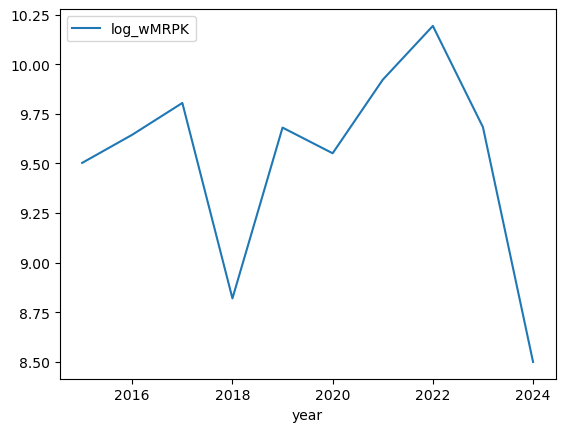

In [7]:
import matplotlib.pyplot as plt

dispt.plot(x='year', y='log_wMRPK')
plt.show()